In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from tqdm import tqdm

In [2]:
import scienceplots
plt.style.use(['science', 'no-latex'])

In [3]:
two_dim = False
inputname = 'runs/25_9/H_input_2025-09-25_18-41-35.txt'
outputname=inputname.replace('input', 'output')
logname=inputname.replace('input', 'log')
orbit_plot = True
input_plot = False #if True plots the initial distribution from the input
density_plot = False

In [4]:
def input_opening(inputname = ''):
    inputf = open(inputname, 'r')

    N = int(inputf.readline())
    n_dim = int(inputf.readline())
        
    t_0 = float(inputf.readline())

    mass_0 = []
    for i in range(3, N+3):
        mass_0.append(float(inputf.readline()))
        
    mass_0 = np.array(mass_0)
    
    #the initial positions are arranged in an array where the first index gives the particle 
    #and the second gives the direction
    position_0 = []
    for i in range(N+4, 2*N + 4):
        position_0.append((inputf.readline()).rstrip())
        
    position_0 = [p.split() for p in position_0]

    for i in range(N):
        for j in range(n_dim):
            position_0[i][j] = float(position_0[i][j])
            
    position_0 = np.array(position_0)

    #the initial velocities are arranged just like the positions
    velocity_0 = []
    for i in range(2*N + 5, 3*N + 5):
        velocity_0.append((inputf.readline()).rstrip())
        
    velocity_0 = [v.split() for v in velocity_0]

    for i in range(N):
        for j in range(n_dim):
            velocity_0[i][j] = float(velocity_0[i][j])
            
    velocity_0 = np.array(velocity_0)
    inputf.close() 
    
    return N, t_0, mass_0, position_0, velocity_0

In [5]:
import os
cores = os.cpu_count()
print(f"You have {cores} CPU cores.")

You have 20 CPU cores.


In [6]:
from concurrent.futures import ThreadPoolExecutor

def parse_snapshot_at_offset(filename, offset):
    """
    Parse a single snapshot starting at file byte offset.
    Returns a dict with parsed data.
    """
    with open(filename, 'r') as f:
        f.seek(offset)
        
        N = int(f.readline().strip())
        D = int(f.readline().strip())
        t = float(f.readline().strip())
        
        # Skip masses
        for _ in range(N):
            f.readline()
        
        positions = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        velocities = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        
        return {
            'N': N,
            'D': D,
            'time': t,
            'positions': np.array(positions),
            'velocities': np.array(velocities)
        }

def find_snapshot_offsets(filename):
    """
    Scan the file once to find byte offsets where each snapshot starts.
    """
    offsets = []
    with open(filename, 'r') as f:
        while True:
            pos = f.tell()
            line = f.readline()
            if not line:
                break
            # If line looks like a snapshot start (N)
            if line.strip().isdigit():
                offsets.append(pos)
                # Skip N, D, time, masses, positions, velocities to get to next snapshot
                N = int(line.strip())
                D = int(f.readline().strip())
                # 1 line for time + N for masses + N for positions + N for velocities
                to_skip = 1 + N*3
                for _ in range(to_skip):
                    f.readline()
            else:
                # If format guarantees snapshot starts with N, else ignore line
                continue
    return offsets

def parallel_parse(filename, max_workers=4):
    offsets = find_snapshot_offsets(filename)
    print(f"Found {len(offsets)} snapshots.")

    results = []
    # usa ThreadPoolExecutor invece di ProcessPoolExecutor
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(parse_snapshot_at_offset, filename, off) for off in offsets]
        for future in futures:
            results.append(future.result())

    # Check consistency
    N = results[0]['N']
    D = results[0]['D']

    times = np.array([r['time'] for r in results])
    positions = np.array([r['positions'] for r in results])  # (snapshots, N, D)
    velocities = np.array([r['velocities'] for r in results])  # (snapshots, N, D)

    # Transpose to (N, snapshots, D)
    positions = positions.transpose(1, 0, 2)
    velocities = velocities.transpose(1, 0, 2)

    return N, D, len(results), times, positions, velocities


In [7]:
n_particles, init_t, mass, init_p, init_v = input_opening(inputname)

In [8]:
if __name__ == '__main__':
    filename = outputname
    N, n_dim, snap_number, time, positions, velocities = parallel_parse(filename, max_workers=cores-2)

Found 713 snapshots.


In [9]:
print(f"Loaded {snap_number} snapshots with {N} particles and {n_dim} dimensions.")

Loaded 713 snapshots with 30001 particles and 3 dimensions.


### Saving CoM

In [10]:
def shrinking_sphere_com(pos, vel, mass, r0, center_init, f, r_min, eps, max_iter=100):
    if center_init is None:
        center = np.mean(pos, axis=0) 
    else:
        center = np.array(center_init, dtype=float)
    
    r = r0 #initial search radius
    for i in range(max_iter): # select particles inside radius r
        disp = pos - center
        dist = np.linalg.norm(disp, axis=1)
        inside = dist <= r
        
        if np.sum(inside) < 100: #if no particles inside sphere
            break
            
        m_in = mass[inside]
        pos_in = pos[inside]
        vel_in = vel[inside]
        
        com_new = np.sum(pos_in * m_in[:,None], axis=0) / np.sum(m_in)
        vel_com_new = np.sum(vel_in * m_in[:,None], axis=0) / np.sum(m_in)
        
        delta = np.linalg.norm(com_new - center)
        center = com_new
        
        r *= f
        if r < r_min or delta < eps:
            break

    return center, vel_com_new, r 

In [11]:
center = np.empty((snap_number, 3))
vel_com = np.empty((snap_number, 3))
r = np.empty(snap_number)

for i in tqdm(range(snap_number)):
    c, v, rad = shrinking_sphere_com(positions[1:, i, :], velocities[1:, i, :], mass[1:], 20.0, None, 0.8, 1e-5, 1e-8, 100)
    center[i]  = c
    vel_com[i] = v
    r[i]       = rad

100%|█████████████████████████████████████████████████████████████████████████████████| 713/713 [00:23<00:00, 30.38it/s]


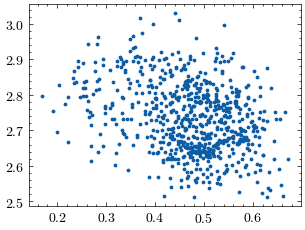

In [12]:
plt.scatter(center[:, 0], center[:, 1], s = 3)

In [13]:
def smooth_com(com_array, window=5):
    """
    Media mobile sul centro di massa.
    
    Parameters
    ----------
    com_array : array (n_snap, 3)
        COM a ogni snapshot.
    window : int
        Larghezza finestra (deve essere dispari).
        
    Returns
    -------
    smoothed : array (n_snap, 3)
        COM smussato.
    """
    if window % 2 == 0:
        raise ValueError("La finestra deve essere dispari (es. 5, 7, 9).")

    n_snap = com_array.shape[0]
    smoothed = np.zeros_like(com_array)
    half = window // 2

    for i in range(n_snap):
        i0 = max(0, i - half)
        i1 = min(n_snap, i + half + 1)
        smoothed[i] = np.mean(com_array[i0:i1], axis=0)
    
    return smoothed

In [14]:
center_smooth_0 = smooth_com(center[:600], window=13)
vel_com_smooth_0 = smooth_com(vel_com[:600], window=13)
center_smooth_1 = smooth_com(center[600:], window=7)
vel_com_smooth_1 = smooth_com(vel_com[600:], window=7)

In [15]:
center_smooth = np.concatenate((center_smooth_0, center_smooth_1))
vel_com_smooth = np.concatenate((vel_com_smooth_0, vel_com_smooth_1))
np.shape(center_smooth)

(713, 3)

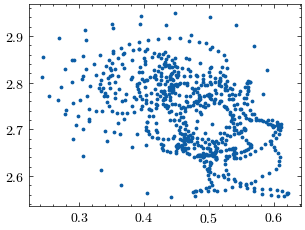

In [16]:
plt.scatter(center_smooth[:, 0], center_smooth[:, 1], s = 3)

In [17]:
pos_BH = positions[0, :, :] - center_smooth
vel_BH = velocities[0, :, :] -  center_smooth

In [18]:
r_BH = np.sqrt(pos_BH[:, 0]**2 + pos_BH[:, 1]**2 + pos_BH[:,2]**2)

### Computing radial quantities

In [19]:
radius = []
for i in range(n_particles): radius.append(np.sqrt(positions[i, :, 0]**2 + positions[i, :, 1]**2 + positions[i, :, 2]**2))
radius = np.array(radius)

### System mp4

### IU -> PU

In [20]:
#conversioni
MSOL_PER_IU = 1E10
KPC_PER_IU = 1.0
KMS_PER_IU = 207.38652969844208
MYR_PER_IU = 4.714829951118732  
#softening usato nel treecode
soft_pair = 0.06 # kpc

### System Energy

### Lagrangian radii

### 2D orbit

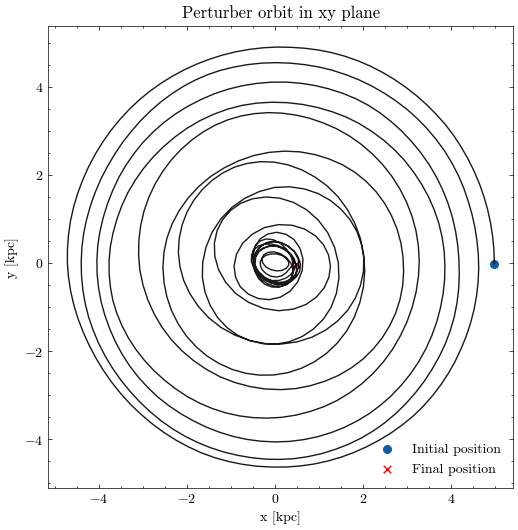

M_1 =  0.007


In [21]:
plt.figure(figsize=(6,6))

#BH1 
plt.plot(pos_BH[:, 0], pos_BH[:, 1], c = 'black', linestyle = '-', alpha = 0.9)
plt.scatter(pos_BH[0, 0], pos_BH[0, 1], c = 'C0', s=30, marker="o", label="Initial position")
plt.scatter(pos_BH[-1, 0], pos_BH[-1, 1], s=30, c = 'r', marker="x", label = 'Final position')

#plt.plot(center[:,0], center[:,1], 'k--', lw=1)

plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.title("Perturber orbit in xy plane")
plt.legend()
plt.axis("equal")
#plt.ylim(-1, 1)
#plt.xlim(-1, 1)
#plt.savefig('plots/007_orbit_2.png', dpi = 400)
plt.show()

print('M_1 = ', mass[0])

### BH radius

In [22]:
time_Myr = time * MYR_PER_IU

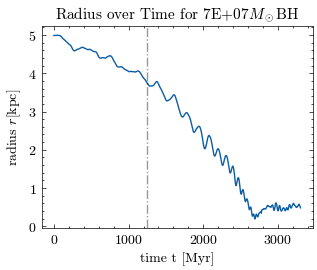

In [23]:
plt.plot(time_Myr, r_BH)
plt.xlabel(r'time t [Myr]')
plt.axvline(time_Myr[270], c = 'black', linestyle = '-.', alpha = 0.4)
plt.ylabel(r"radius $r$[kpc]")  # 1 IU = 1 kpc
plt.title('Radius over Time for ' + f"{10**10*mass[0]:.0E}" + r'$M_\odot$' + 'BH', fontsize = 11)
plt.savefig('plots/007_radius.png', dpi = 400)
plt.show()

In [24]:
time_Myr[270]

np.float64(1251.966609856765)

### Angular momentum

In [25]:
L_BH = mass[0] * np.cross(pos_BH[:], vel_BH[:])
L_BH= np.sqrt(L_BH[:, 0]**2 + L_BH[:, 1]**2 + L_BH[:, 2]**2) #modulo rispetto al centro di massa

In [26]:
L_BH_0 = mass[0] * np.cross(pos_BH[:], vel_BH[:])

Text(0, 0.5, '$L_z$')

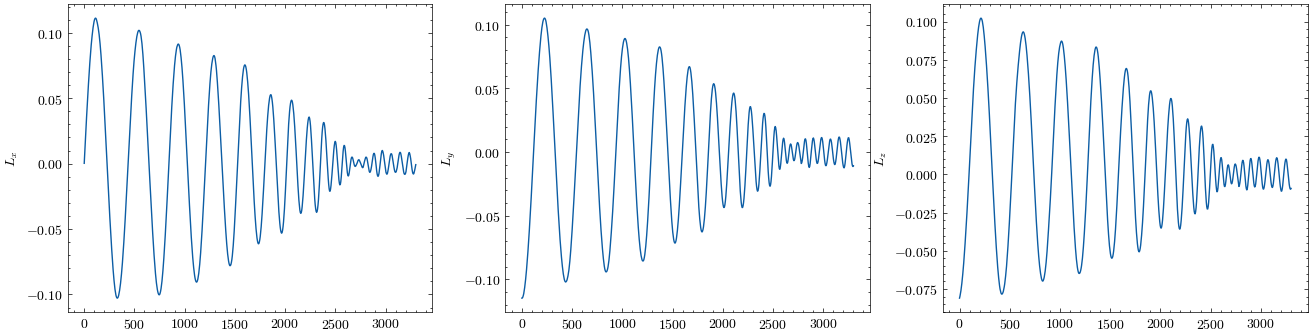

In [27]:
fig, ax = plt.subplots(1, 3, figsize = (16, 4))
ax[0].plot(time_Myr, L_BH_0[:, 0])
ax[0].set_ylabel(r'$L_x$')

ax[1].plot(time_Myr, L_BH_0[:, 1])
ax[1].set_ylabel(r'$L_y$')

ax[2].plot(time_Myr, L_BH_0[:, 2])
ax[2].set_ylabel(r'$L_z$')

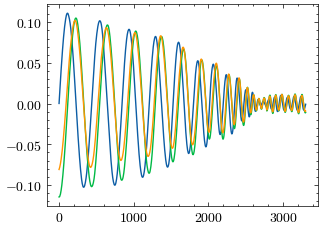

In [28]:
plt.plot(time_Myr, L_BH_0[:, 0])
plt.plot(time_Myr, L_BH_0[:, 1])
plt.plot(time_Myr, L_BH_0[:, 2])

We fix the angular momentum threshold by taking the mean of the last snapshots, where we assume dynamical friction to have ended and the variation of L to be due to numerical noise.

In [29]:
L_conversion = 1 #MSOL_PER_IU * KPC_PER_IU**2 / MYR_PER_IU

In [30]:
L_threshold = np.mean(L_BH[600:]) * L_conversion
L_percent = (L_threshold / L_BH[0]) * 100

print(f'|L| threshold = {L_threshold:.5f} corresponding to of {L_percent:.2f}% the initial value.')

|L| threshold = 0.01154 corresponding to of 8.22% the initial value.


In [31]:
interval = 5
xx = np.linspace(0, int(snap_number/interval) -  5, int(snap_number/interval) - 5, dtype = int) *5
means = [np.mean(L_BH[i:i+interval]) for i in xx]

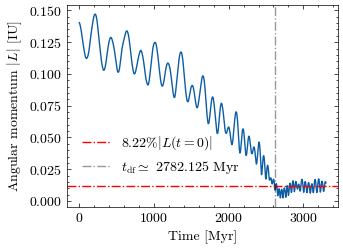

In [34]:
idx = np.array( np.where(np.isclose(L_BH, L_threshold, atol = 1e-3))[0] )
t_idx = idx * interval

plt.plot(time_Myr, L_BH * L_conversion)
#plt.plot(time_Myr[xx], means)
plt.axhline(L_threshold * L_conversion, c = 'r', linestyle = '-.', label = f'{L_percent:.2f}%' + r'$|L(t=0)|$')
plt.xlabel("Time [Myr]")
plt.axvline(time_Myr[idx[0]], c = 'black', linestyle = '-.', alpha = 0.4, label = r'$t_\mathrm{df} \simeq$ ' + f'{time_Myr[idx[2]]:.3f} ' + 'Myr')
plt.ylabel("Angular momentum $|L|$ [IU]")
plt.legend(loc = 'lower left', bbox_to_anchor = (0.01, 0.09))
#plt.savefig('plots/007_L.png', dpi = 400)
plt.show()

In [35]:
idx

array([564, 567, 600, 601, 607, 610, 619, 623, 628, 632, 635, 640, 646,
       650, 655, 660, 664, 670, 673, 678, 684, 688, 694, 698, 703, 708])

In [36]:
time_Myr[idx[2]]

np.float64(2782.1252073656588)

In [37]:
dt_df = max(time_Myr[t_idx[1]] - time_Myr[t_idx[0]], time_Myr[t_idx[2]] - time_Myr[t_idx[1]])

IndexError: index 2835 is out of bounds for axis 0 with size 713

In [38]:
print(f'Esitimated t_df = {time_Myr[t_idx[1]]:.3f} +- {dt_df:.3f}')

IndexError: index 2835 is out of bounds for axis 0 with size 713

In [39]:
time_Myr[t_idx[0]]

IndexError: index 2820 is out of bounds for axis 0 with size 713

### Escaped particles

In [40]:
M_H = 1.0
a = 2.0
r_escape = r_lag_all[0, -1]

def v_escape (radius):
    return np.sqrt(2*M_H / (radius + a))

n_escape = 0.0
mask_escape = []

for i in tqdm(range(1, n_particles)):
    for j in range(snap_number):
        if radius[i, j] > r_escape and radial_v[i, j] >= v_escape(r_escape):
            #print('particle number ', i, f'escaped at time {time[j]:.2f}')
            mask_escape.append(i)
            n_escape += 1
            break

print('tot # of escaped particles = ', n_escape, ', corresponding to ', n_escape/n_particles, ' of the system.')

NameError: name 'r_lag_all' is not defined

In [ ]:
plt.plot(time, center_r[:], s= 1)